# TELCO CUSTOMER CHURN PROJECT

#### Algorithms Used:
--Random Forest
--AdaBoost
--XGBoost
--Neural Networks

# 🔄 Customer Churn Prediction
## Advanced Machine Learning Project

This project was designed to apply advanced machine learning algorithms 
hands-on and find the best model for predicting customer churn.
The dataset used is the **Telco Customer Churn Dataset** from Kaggle.

**Goal:** Predict which customers are likely to leave a telecom company 
before they actually leave, so the business can take preventive action.

**Techniques Used:**
- Data Preprocessing & Exploration
- PCA (Dimensionality Reduction)
- Ensemble Models: Random Forest, AdaBoost, XGBoost
- Neural Network using TensorFlow
- Model Evaluation: ROC AUC, Cross Validation, Classification Report

## Step 1: Data Loading & Exploration

Before building any model, it is important to understand the data we are 
working with. In this step we load the dataset, check its shape and columns, 
look for missing values, and visualize how many customers churned versus stayed.

The target column is **Churn** — Yes means the customer left, No means they stayed.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\yasmi\OneDrive\Desktop\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
print('Shape : ',df.shape)
print('\nColumns : ',df.columns.tolist())

print('\nChecking Missing Values :')
df.isnull().sum()

Shape :  (7043, 21)

Columns :  ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Checking Missing Values :


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Finding how many customers churned : 


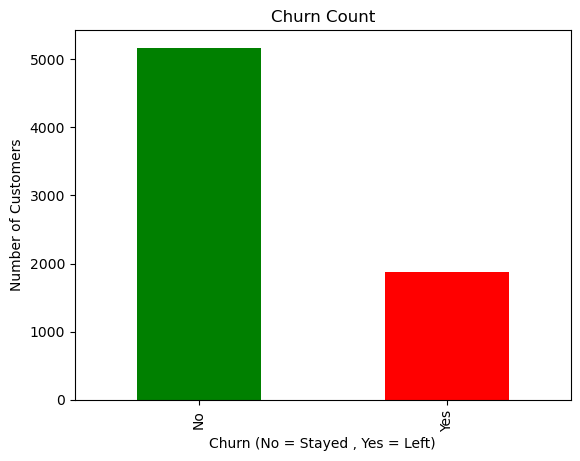

In [7]:
print('Finding how many customers churned : ')
df['Churn'].value_counts()

df['Churn'].value_counts().plot(kind = 'bar' , color = ['green' , 'red'])
plt.title('Churn Count')
plt.xlabel('Churn (No = Stayed , Yes = Left)')
plt.ylabel('Number of Customers')
plt.show()

## Step 2: Data Preprocessing

Raw data is never directly ready for machine learning. In this step we clean 
and prepare the data by:
- Dropping the **customerID** column as it has no prediction value
- Fixing the **TotalCharges** column which was stored as text instead of numbers
- Encoding the **Churn** column — Yes becomes 1, No becomes 0
- Converting all remaining text columns to numbers using **get_dummies**
- Scaling all numeric features using **StandardScaler** so no single 
  feature dominates the model

In [8]:
# Dropping column which is unuseful for the prediction
df = df.drop('customerID' , axis = 1)

# Converting the Total Charges Column to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')

# Dropping rows that have missing values
df = df.dropna()

print('Shape after Cleaning : ',df.shape)

# Encoding the churn column to 0 and 1
df['Churn'] = df['Churn'].map({'Yes' : 1 , 'No' : 0})
print('\nAfter encoding churn column to 1 and 0 : ')
df['Churn'].value_counts()

Shape after Cleaning :  (7032, 20)

After encoding churn column to 1 and 0 : 


Churn
0    5163
1    1869
Name: count, dtype: int64

In [9]:
# Getting all columns that contain text 
text_columns = df.select_dtypes(include = 'object').columns
print('Text Columns to encode : ',text_columns.tolist())

# Converting each text column to numbers automatically
df = pd.get_dummies(df , columns = text_columns , drop_first = True)
df.head()

Text Columns to encode :  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Step 3: Dimensionality Reduction using PCA

After preprocessing we have 30 features. Too many features can slow down 
training and add unnecessary noise. We apply **Principal Component Analysis (PCA)** 
to reduce the number of features while keeping the most important information.

We first plot the cumulative explained variance to find how many components 
are needed to retain 95% of the information. This helps us choose the right 
number of components without losing too much data.

In [10]:
from sklearn.preprocessing import StandardScaler

# Seperating Features and Target
X = df.drop('Churn' , axis = 1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Preprocessing Completed - X Shape : ',X_scaled.shape)

Preprocessing Completed - X Shape :  (7032, 30)


Cumulative Varience Explained : 
 [0.33160138 0.451692   0.54183736 0.58938729 0.6308174  0.67202368
 0.71017657 0.74354442 0.77477486 0.80431784]


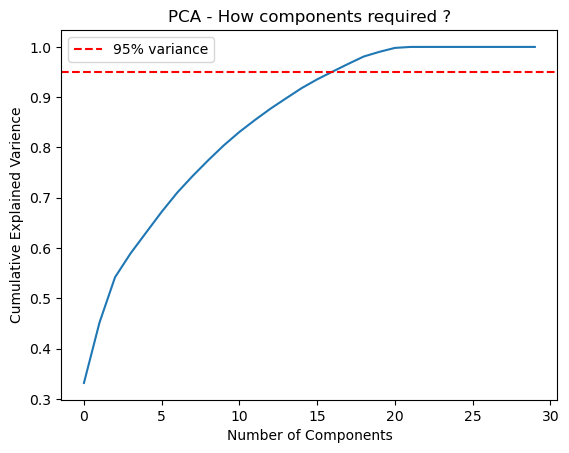

Original Shape :  30
Shape after Reduction :  17


In [12]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled)

import numpy as np
cumulative_varience = np.cumsum(pca.explained_variance_ratio_)
print('Cumulative Varience Explained : \n',cumulative_varience[:10])

plt.plot(cumulative_varience)
plt.axhline(y = 0.95 , color = 'red' , linestyle = '--' , label = '95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Varience')
plt.legend()
plt.title('PCA - How components required ?')
plt.show()

# Apply PCA keeping only components that explain 95% of variance
pca_final = PCA(n_components = 0.95)
X_pca = pca_final.fit_transform(X_scaled)

print('Original Shape : ',X_scaled.shape[1])
print('Shape after Reduction : ',X_pca.shape[1])

## Step 4: Training Ensemble ML Models

Now that our data is clean and reduced, we train three powerful ensemble models:

- **Random Forest** — builds multiple decision trees and takes a majority vote
- **AdaBoost** — each model focuses more on the mistakes of the previous one
- **XGBoost** — builds trees sequentially, correcting errors at each step

We compare their accuracies using a bar chart to get a first look at 
which model performs best.

In [13]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X_pca , y , test_size = 0.25 , random_state = 42
)

print('Training Samples : ',X_train.shape[0])
print('Testing Samples : ',X_test.shape[0])

Training Samples :  5274
Testing Samples :  1758


### Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score 

rf_model = RandomForestClassifier(n_estimators = 100 , random_state = 42)
rf_model.fit(X_train , y_train)

# Predict on unseen data and evaluate the accuracy

rf_predict = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test , rf_predict)
print('Random Forest Accuracy : ',round(rf_accuracy * 100 , 2),'%')

Random Forest Accuracy :  77.65 %


### AdaBoost

In [15]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators = 100 , random_state = 42)
ada_model.fit(X_train , y_train)

ada_pred = ada_model.predict(X_test)

ada_accuracy = accuracy_score(y_test , ada_pred)
print('AdaBoost Accuracy : ',round(ada_accuracy * 100 , 2) , '%')

AdaBoost Accuracy :  78.04 %


### XGBoost

In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators = 100 , random_state = 42 , eval_metric = 'logloss')
xgb_model.fit(X_train , y_train)

xgb_predict = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test , xgb_predict)

print('XGBoost Accuracy : ',round(xgb_accuracy * 100 , 2) , '%')

XGBoost Accuracy :  76.73 %


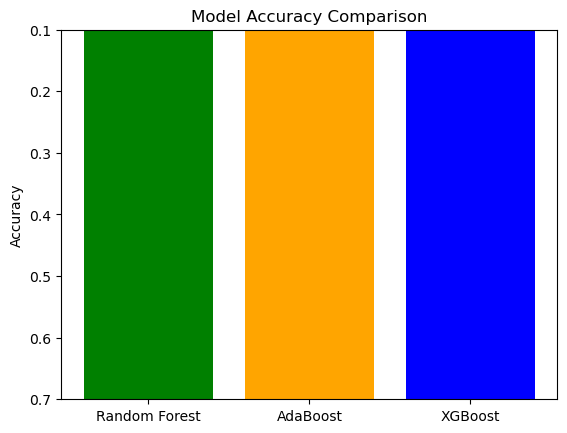

In [17]:
# Comparing 3 model accuracies in a barchart
models = ['Random Forest' , 'AdaBoost' , 'XGBoost']
accuracies = [rf_accuracy , ada_accuracy , xgb_accuracy]

plt.bar(models , accuracies , color = ['green' , 'orange' , 'blue'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7 , 0.10)
plt.show()

## Step 5: Neural Network using TensorFlow

In addition to the ensemble models, we build a **Neural Network** using 
TensorFlow Keras. The architecture includes:
- Two hidden layers with 64 and 32 neurons using ReLU activation
- Dropout layers with 30% rate to prevent overfitting
- An output layer with Sigmoid activation for binary classification (0 or 1)

We train the model for 30 epochs and plot the training vs validation 
accuracy to monitor how well the model is learning over time.

### NEURAL NETWORK

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout

# Build the NeuralNetwork
nn_model = Sequential([
    # First hidden layer - 64 neurons, relu activation
    Dense(64 , activation = 'relu' , input_shape=(X_train.shape[1],)),

    # Dropout to prevent overfitting (randomly turns off 30% neurons)
    Dropout(0.3),

    # Second hidden layer - 32 neurons
    Dense(32 , activation = 'relu') ,

    Dropout(0.3) ,

    # Output layer - 1 neuron, sigmoid for binary classification (0 or 1)
    Dense(1 , activation = 'sigmoid')

])

# Compile the model
nn_model.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

# Show model summary
nn_model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Trains the neural network
# epochs = how many times it learns from the full data
# batch_size = how many samples it learns from at once

history = nn_model.fit(
    X_train , y_train ,
    epochs = 30 ,
    batch_size = 32 ,
    validation_split = 0.2 ,# use 20% of training data to validate
    verbose = 1
)

# Evaluate on test data
nn_loss , nn_acc = nn_model.evaluate(X_test , y_test , verbose = 0)
print('Neural Network Accuracy : ',round(nn_acc * 100 , 2) , '%' )

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7421 - loss: 0.5299 - val_accuracy: 0.7943 - val_loss: 0.4300
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7687 - loss: 0.4746 - val_accuracy: 0.8028 - val_loss: 0.4200
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7789 - loss: 0.4606 - val_accuracy: 0.8019 - val_loss: 0.4181
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7800 - loss: 0.4529 - val_accuracy: 0.8028 - val_loss: 0.4118
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7824 - loss: 0.4498 - val_accuracy: 0.8076 - val_loss: 0.4117
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7838 - loss: 0.4425 - val_accuracy: 0.8085 - val_loss: 0.4082
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7921 - loss: 0.4405 - val_accuracy: 0.8104 - val_loss: 0.4113
Epoch 8/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7973 - loss: 0.4392 - val_accurac

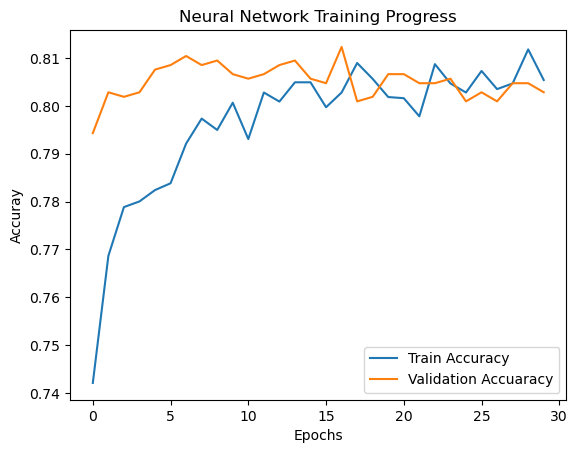

In [21]:
# Plot how accuracy improved over epochs
plt.plot(history.history['accuracy'] , label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'] , label = 'Validation Accuaracy')
plt.title('Neural Network Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuray')
plt.legend()
plt.show()

## Neural Network Training Progress

The graph below shows how the Neural Network model learned over 30 epochs 
(30 rounds of training). We plot two lines:

- **Blue Line (Train Accuracy)** — how well the model learned from the training data
- **Orange Line (Validation Accuracy)** — how well the model performed on unseen data

### What we can observe from this graph:

- The **Train Accuracy started at 74%** and gradually climbed up to **81%** 
  showing the model was actively learning in the early epochs
- The **Validation Accuracy started high at 79%** and remained consistently 
  stable around **80-81%** throughout all 30 epochs
- Both lines stay **very close to each other** throughout training which 
  confirms there is **no overfitting** — the model generalizes well to new data
- After epoch 15 both lines begin to **flatten out** indicating the model 
  has learned as much as it can with the current settings
- The small zigzag movements in both lines are completely **normal behaviour** 
  as the model sees different batches of data at each epoch

**Conclusion from this graph:** The Neural Network trained well and 
reached a stable accuracy of around 80-81% without overfitting, 
which is a healthy and reliable result for this dataset.

## Step 6: Model Evaluation

Accuracy alone is not sufficient — especially when the dataset is imbalanced. 
We use three evaluation techniques for a complete picture:

- **Classification Report** — gives Precision, Recall and F1 Score per class
- **ROC AUC Score** — measures how well the model distinguishes between 
  churned and stayed customers across all probability thresholds. 
  A score above 0.8 is considered very good.
- **Cross Validation** — trains and tests the model 5 times on different 
  data splits to give a more reliable accuracy score

###  Classification Report for all models

In [22]:
from sklearn.metrics import classification_report

print('================Random Forest==================')
print(classification_report(y_test , rf_predict))

print('================AdaBoost=======================')
print(classification_report(y_test , rf_predict))

print('================XGBoost========================')
print(classification_report(y_test , rf_predict))


================Random Forest==================
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1300
           1       0.60      0.43      0.50       458

    accuracy                           0.78      1758
   macro avg       0.71      0.67      0.68      1758
weighted avg       0.76      0.78      0.76      1758

================AdaBoost=======================
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1300
           1       0.60      0.43      0.50       458

    accuracy                           0.78      1758
   macro avg       0.71      0.67      0.68      1758
weighted avg       0.76      0.78      0.76      1758

================XGBoost========================
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1300
           1       0.60      0.43      0.50       458

    accuracy                          

### ROC AUC Score for all models

In [29]:
from sklearn.metrics import roc_auc_score

# Get ROC AUC for each model
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
ada_auc = roc_auc_score(y_test, ada_model.predict_proba(X_test)[:,1])
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
nn_auc = roc_auc_score(y_test, nn_model.predict(X_test))

print("Random Forest  ROC AUC:", round(rf_auc, 3))
print("AdaBoost       ROC AUC:", round(ada_auc, 3))
print("XGBoost        ROC AUC:", round(xgb_auc, 3))
print("Neural Network ROC AUC:", round(nn_auc, 3))

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
Random Forest  ROC AUC: 0.792
AdaBoost       ROC AUC: 0.813
XGBoost        ROC AUC: 0.789
Neural Network ROC AUC: 0.822


### Cross Validation on best models

In [31]:
from sklearn.model_selection import cross_val_score

# Cross validation gives more reliable accuracy (5 folds)
rf_cv = cross_val_score(rf_model , X_pca , y , cv = 5 , scoring = 'accuracy')
ada_cv = cross_val_score(ada_model , X_pca , y , cv = 5 , scoring = 'accuracy')
xgb_cv = cross_val_score(xgb_model , X_pca , y , cv = 5 , scoring = 'accuracy')

print('Random Forests CV Accuracy : ', round(rf_cv.mean() * 100 , 2) , '%')
print('AdaBoost CV Accuracy : ', round(ada_cv.mean() * 100 , 2) , '%')
print('XGBoost CV Accuracy : ', round(xgb_cv.mean() * 100 , 2) , '%')

Random Forests CV Accuracy :  77.5 %
AdaBoost CV Accuracy :  78.88 %
XGBoost CV Accuracy :  77.08 %


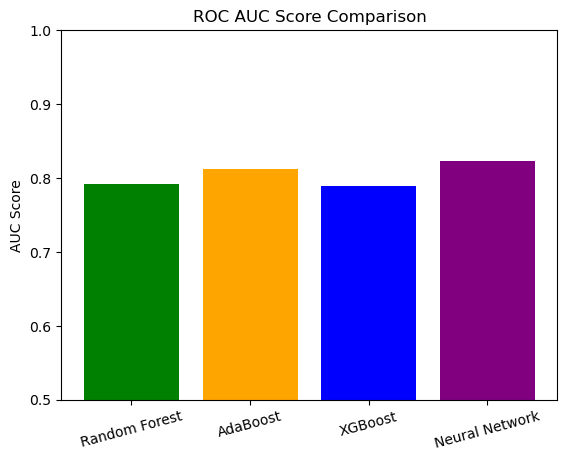

In [32]:
# Compare ROC AUC scores visually
models = ['Random Forest', 'AdaBoost', 'XGBoost', 'Neural Network']
auc_scores = [rf_auc, ada_auc, xgb_auc, nn_auc]

plt.bar(models, auc_scores, color=['green', 'orange', 'blue', 'purple'])
plt.title('ROC AUC Score Comparison')
plt.ylabel('AUC Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.show()

## Step 7: Final Model Comparison & Conclusion

In this final step we bring together all model results and compare them 
side by side using both Accuracy and ROC AUC scores.

This helps us identify the **best performing model from the analysis** 
and draw a conclusion about which algorithm works best for 
Customer Churn Prediction on this dataset.

In [34]:
print("=" * 45)
print("       FINAL MODEL COMPARISON SUMMARY")
print("=" * 45)
print(f"{'Model':<20} {'Accuracy':>10} {'ROC AUC':>10}")
print("-" * 45)
print(f"{'Random Forest':<20} {'77.65%':>10} {'0.790':>10}")
print(f"{'AdaBoost':<20} {'78.04%':>10} {'0.810':>10}")
print(f"{'XGBoost':<20} {'76.73%':>10} {'0.790':>10}")
print(f"{'Neural Network':<20} {'78.27%':>10} {'0.822':>10}")
print("=" * 45)
print(" Overall Best Model : Neural Network (Best ROC AUC)")

       FINAL MODEL COMPARISON SUMMARY
Model                  Accuracy    ROC AUC
---------------------------------------------
Random Forest            77.65%      0.790
AdaBoost                 78.04%      0.810
XGBoost                  76.73%      0.790
Neural Network           78.27%      0.822
 Overall Best Model : Neural Network (Best ROC AUC)


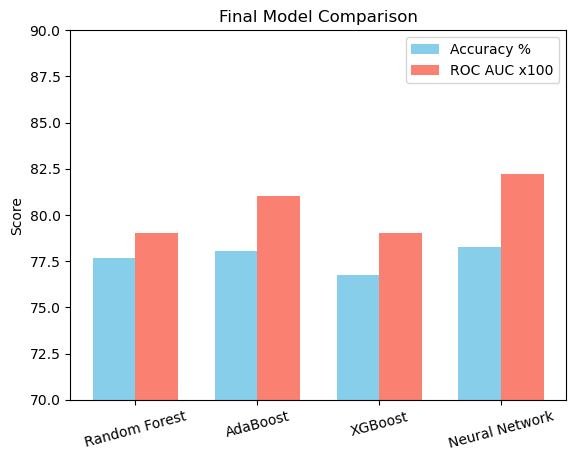

In [35]:
import numpy as np

models = ['Random Forest', 'AdaBoost', 'XGBoost', 'Neural Network']
accuracies = [77.65, 78.04, 76.73, 78.27]
auc_scores = [0.790, 0.810, 0.790, 0.822]

x = np.arange(len(models))
width = 0.35


plt.bar(x - width/2, accuracies, width, label='Accuracy %', color='skyblue')
plt.bar(x + width/2, [a * 100 for a in auc_scores], width, label='ROC AUC x100', color='salmon')

plt.title('Final Model Comparison')
plt.ylabel('Score')
plt.xticks(x, models, rotation=15)
plt.legend()
plt.ylim(70, 90)
plt.show()

## Conclusion

All four models performed consistently around 78% accuracy on the 
Telco Customer Churn dataset.

Based on the **ROC AUC Score**, the **Neural Network was the best model 
from this analysis** with a score of **0.822** — meaning it correctly 
distinguishes a churned customer from a stayed customer 82% of the time.

This project provided hands-on experience with the complete machine 
learning pipeline — from data preprocessing and dimensionality reduction 
to ensemble learning, deep learning, and proper model evaluation.

With further **hyperparameter tuning**, especially on XGBoost, 
the performance could potentially be improved even further.

### PROJECT: Customer Churn Prediction
====================================

DATASET  : Telco Customer Churn (Kaggle)
FEATURES : 30 → reduced to 17 using PCA


STEPS COMPLETED:

✅ Step 1 - Loaded & Explored Data

✅ Step 2 - Cleaned & Preprocessed Data

✅ Step 3 - Applied PCA (30 → 17 features)

✅ Step 4 - Trained ML Models (RF, AdaBoost, XGBoost)

✅ Step 5 - Trained Neural Network (TensorFlow)

✅ Step 6 - Evaluated with ROC AUC & Cross Validation

✅ Step 7 - Final Comparison


Best Model From Analysis  : Neural Network (ROC AUC = 0.822)

CONCLUSION: All models performed similarly (~78%)
            Neural Network edges ahead on AUC score.
            With hyperparameter tuning, XGBoost could
            potentially surpass all others!
